<a href="https://colab.research.google.com/github/saadzainab/Used-Car-Price-Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json

# Create Kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Put your Kaggle username and API key here
kaggle_credentials = {
    "username": "zsaadd",
    "key": "KGAT_1e3a2a6fcf4759f04e32da3faaa8d62b"
}

# Save as kaggle.json
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

# Set permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✅ kaggle.json created successfully!")

✅ kaggle.json created successfully!


In [3]:
!pip install -q kaggle
!kaggle datasets download -d abdullahkhanuet22/olx-cars-dataset
!unzip -q olx-cars-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/abdullahkhanuet22/olx-cars-dataset
License(s): CC0-1.0
100% 1.72M/1.72M [00:00<00:00, 140MB/s]



In [4]:
# ============================================================
# Pakistan Used Car Price Prediction
# Phase 1: Project Setup + Data Collection + Initial Inspection
# ============================================================

#Import Required Libraries


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings

warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Load Dataset

df = pd.read_csv("/content/OLX_cars_dataset00.csv")

# Data Summary

df.head()

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Columns in dataset:")

df.columns


df.info()

df.describe()

# Missing Values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]


# Check Duplicate Rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)


#Unique Values Count for Each Column

for column in df.columns:
    print("\nColumn:", column)
    print("Unique values:", df[column].nunique())


# 14. Dataset Preview

df.head(10)

Number of rows: 9179
Number of columns: 18
Columns in dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9179 entries, 0 to 9178
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Ad ID              9179 non-null   int64 
 1   Car Name           9179 non-null   object
 2   Make               9179 non-null   object
 3   Model              9179 non-null   object
 4   Year               9179 non-null   int64 
 5   KM's driven        9179 non-null   int64 
 6   Price              9179 non-null   int64 
 7   Fuel               9179 non-null   object
 8   Registration city  9179 non-null   object
 9   Car documents      9179 non-null   object
 10  Assembly           9179 non-null   object
 11  Transmission       9179 non-null   object
 12  Condition          9179 non-null   object
 13  Seller Location    9179 non-null   object
 14  Description        9179 non-null   object
 15  Car Features       9179 no

,Ad ID,Car Name,Make,Model,Year,KM's driven,Price,Fuel,Registration city,Car documents,Assembly,Transmission,Condition,Seller Location,Description,Car Features,Images URL's,Car Profile
0,1079071571,fresh import Passo 2021model,Toyota,Passo,2021,54000,4190000,Petrol,Unregistered,Original,Imported,Automatic,Used,"Airline Avenue, Islamabad","it's 2021 model fresh import, perfect engine s...","ABS, Air Bags, AM/FM Radio, CD Player, Cassett...",['https://images.olx.com.pk/thumbnails/4039460...,https://www.olx.com.pk/item/fresh-import-passo...
1,1080125520,Suzuki ravi,Suzuki,Ravi,2018,95000,1300000,Petrol,Karachi,Original,Local,Manual,Used,"Kahuta, Rawalpindi",Suzuki ravi 2018 col,AM/FM Radio,['https://images.olx.com.pk/thumbnails/4102504...,https://www.olx.com.pk/item/suzuki-ravi-iid-10...
2,1080748789,Suzuki bolan 2015 contact 03112271054,Suzuki,Bolan,2015,50000,800000,Petrol,Karachi,Original,Local,Manual,Used,"Lyari Expressway, Karachi",Suzuki bolan model 2015 reg 2022 ghadi me koi ...,Rear speakers,['https://images.olx.com.pk/thumbnails/4139520...,https://www.olx.com.pk/item/suzuki-bolan-2015-...
3,1076081635,Diahatsu Move 2013,Daihatsu,Move,2013,94000,2155000,Petrol,Lahore,Original,Imported,Automatic,Used,"New Amir Town, Lahore",Move Push start \nHome Used car. \nModel 2013....,"ABS, Air Bags, Air Conditioning, Alloy Rims, A...",['https://images.olx.com.pk/thumbnails/3865337...,https://www.olx.com.pk/item/diahatsu-move-2013...
4,1080812928,Suzuki Swift DLX 2011 miner tuchap,Suzuki,Swift,2011,126544,1440000,Petrol,Karachi,Original,Local,Manual,Used,"Shadman 2, Karachi",Suzuki Swift DLX\nAbS Break 100%\nengine 100%\...,"ABS, Air Conditioning, Alloy Rims, AM/FM Radio...",['https://images.olx.com.pk/thumbnails/4143509...,https://www.olx.com.pk/item/suzuki-swift-dlx-2...
5,1079496823,WagonR AGS total genuine,Suzuki,Wagon R,2020,54000,2830000,Petrol,Lahore,Original,Local,Automatic,Used,"Abbot Road, Sialkot",wagon r total genuine AGS new tyre,"ABS, Air Bags, Alloy Rims, AM/FM Radio, CD Pla...",['https://images.olx.com.pk/thumbnails/4065083...,https://www.olx.com.pk/item/wagonr-ags-total-g...
6,1080333426,Daihatsu Mira,Daihatsu,Mira,2013,140000,2150000,Petrol,Karachi,Original,Imported,Automatic,Used,"North Nazimabad - Block A, Karachi",bilkul okay condition me hen engine change hen...,"ABS, Air Bags, Air Conditioning, AM/FM Radio, ...",['https://images.olx.com.pk/thumbnails/4114961...,https://www.olx.com.pk/item/daihatsu-mira-iid-...
7,1080784758,Suzuki Bolan 2016 genuine condition low mileage,Suzuki,Bolan,2016,32000,1050000,Petrol,Karachi,Original,Local,Manual,Used,"Korangi Industrial Area, Karachi",SUZUKI BOLANSuzuki Bolan 2016 genuine conditio...,"Alloy Rims, AM/FM Radio",['https://images.olx.com.pk/thumbnails/4141723...,https://www.olx.com.pk/item/suzuki-bolan-2016-...
8,1076448625,2004 Honda City,Honda,City IDSI,2004,160000,1230000,Petrol,Sindh,Original,Local,Manual,Used,"Allama Iqbal Town - Huma Block, Lahore",A very well maintained - Good consumption\nno...,"ABS, Air Conditioning, Alloy Rims, CD Player, ...",['https://images.olx.com.pk/thumbnails/3886393...,https://www.olx.com.pk/item/2004-honda-city-ii...
9,1080820574,car Bashir s 80 janwan Hain 03218823600,Suzuki,Cultus VXR,2008,75000,950000,Petrol,Faisalabad,Original,Local,Manual,Used,"Al Najaf Colony, Faisalabad",Ander s hotel janvan Hain by Matrek avlebal Ha...,"Air Conditioning, AM/FM Radio, CD Player, Cool...",['https://images.olx.com.pk/thumbnails/4143955...,https://www.olx.com.pk/item/car-bashir-s-80-ja...


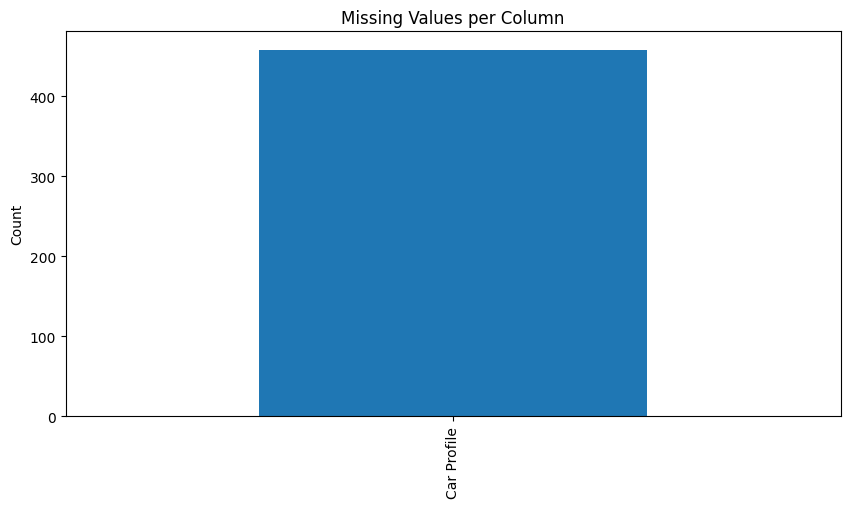

In [5]:
# ============================================================
# Phase 2: Exploratory Data Analysis (EDA)
# ============================================================

# Missing Values

missing = df.isnull().sum()

missing[missing > 0].sort_values(
    ascending=False
)


plt.figure(figsize=(10,5))

missing[missing > 0].plot(
    kind="bar"
)

plt.title("Missing Values per Column")

plt.ylabel("Count")

plt.show()

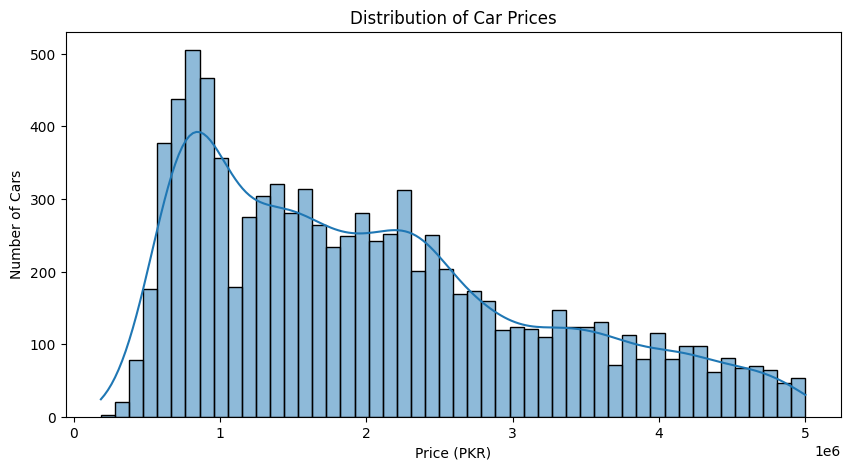

In [6]:

# Price Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df["Price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Car Prices")
plt.xlabel("Price (PKR)")
plt.ylabel("Number of Cars")

plt.show()

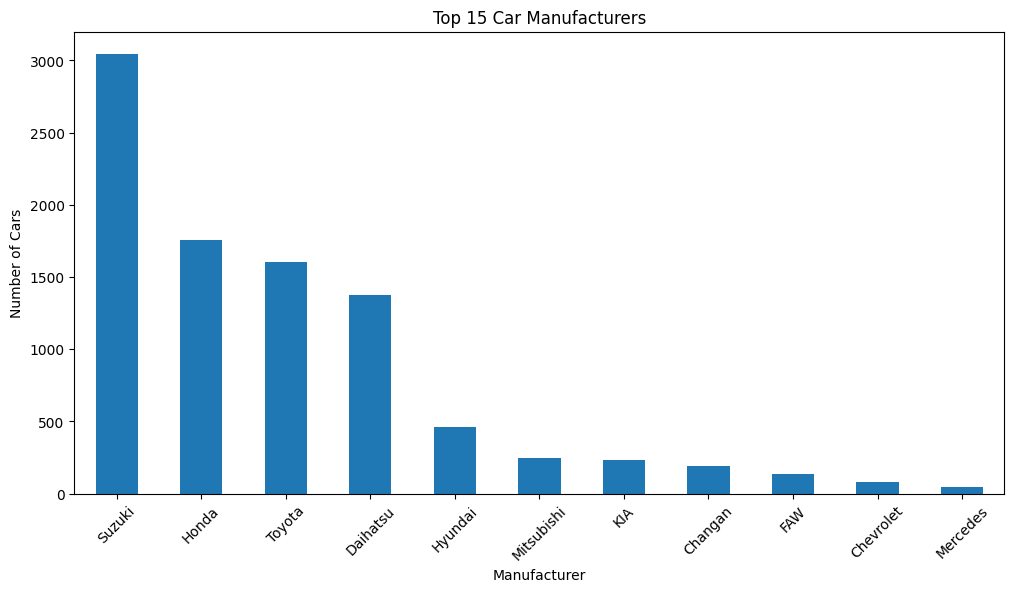

In [7]:
# Most Common Car Manufacturers


plt.figure(figsize=(12,6))

df["Make"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Car Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

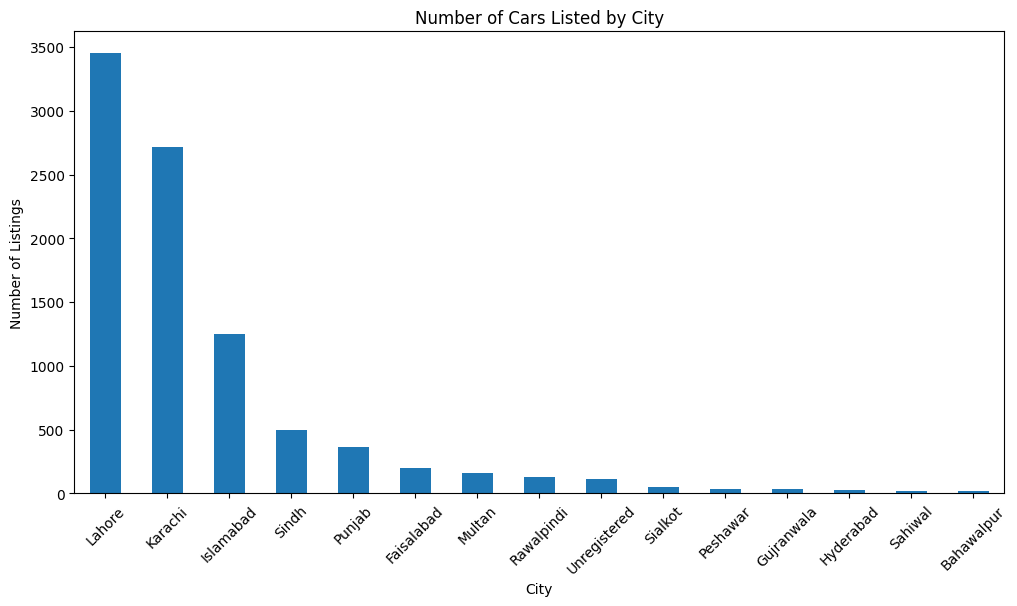

In [ ]:
# 7. Cars by City

plt.figure(figsize=(12,6))

df["Registration city"].value_counts().head(15).plot(kind="bar")

plt.title("Number of Cars Listed by City")

plt.xlabel("City")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()

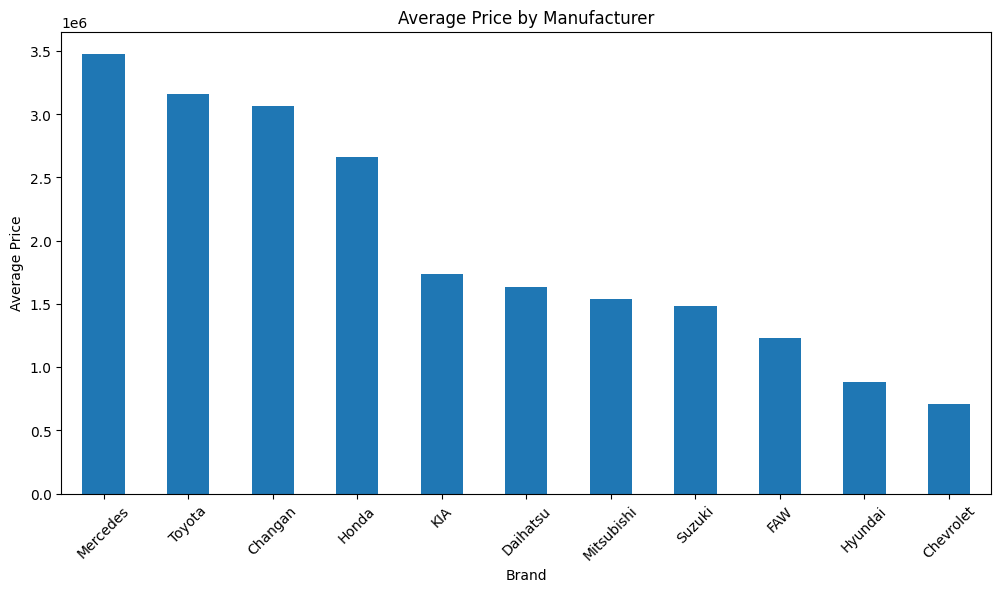

In [ ]:
# Average Price by Brand


brand_price = (
    df.groupby("Make")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)


plt.figure(figsize=(12,6))

brand_price.plot(
    kind="bar"
)

plt.title("Average Price by Manufacturer")

plt.xlabel("Brand")

plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

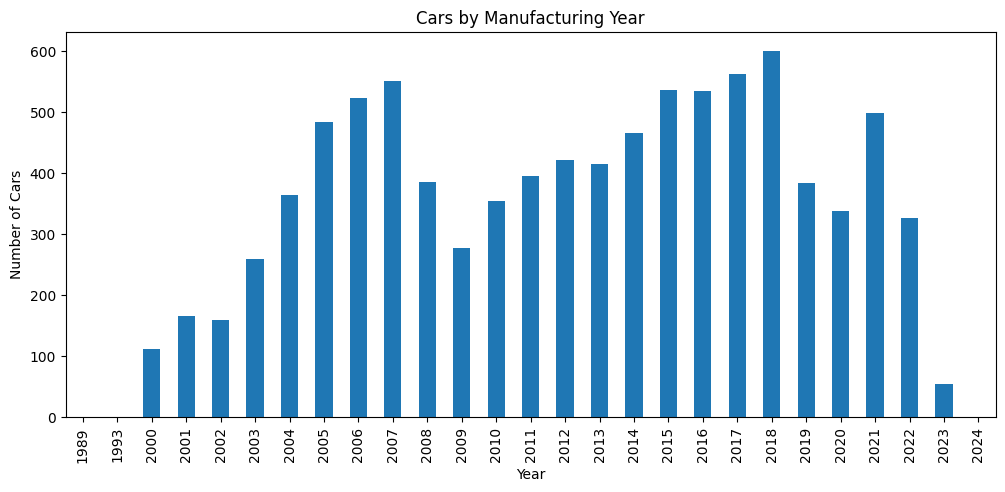

In [ ]:
# Manufacturing Year Distribution

plt.figure(figsize=(12,5))

df["Year"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cars by Manufacturing Year")

plt.xlabel("Year")

plt.ylabel("Number of Cars")

plt.show()

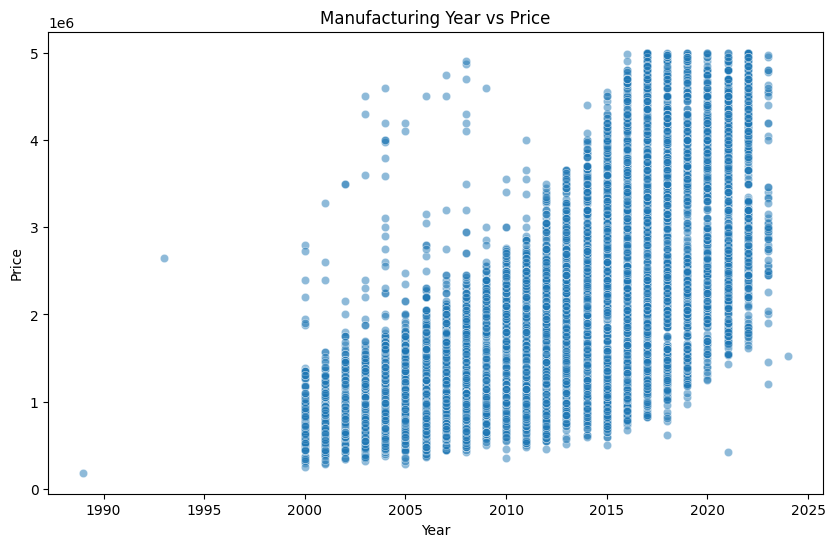

In [ ]:
# Year vs Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Price",
    alpha=0.5
)

plt.title("Manufacturing Year vs Price")

plt.show()

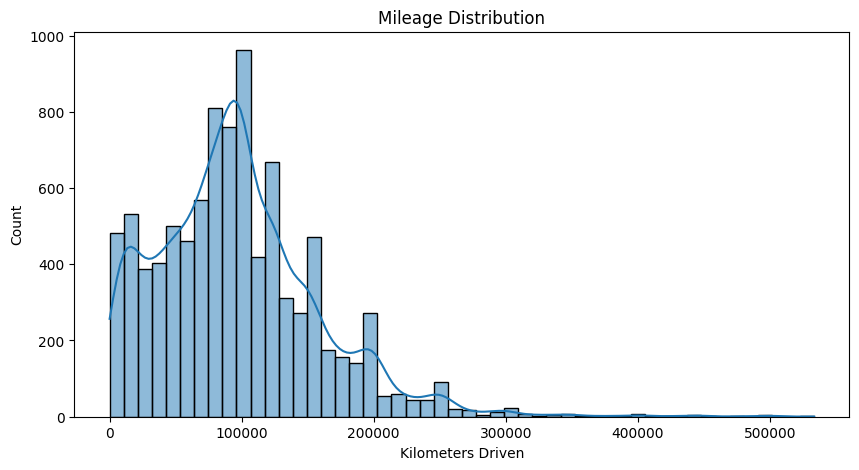

In [ ]:
# Mileage Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df["KM's driven"],
    bins=50,
    kde=True
)

plt.title("Mileage Distribution")

plt.xlabel("Kilometers Driven")

plt.show()

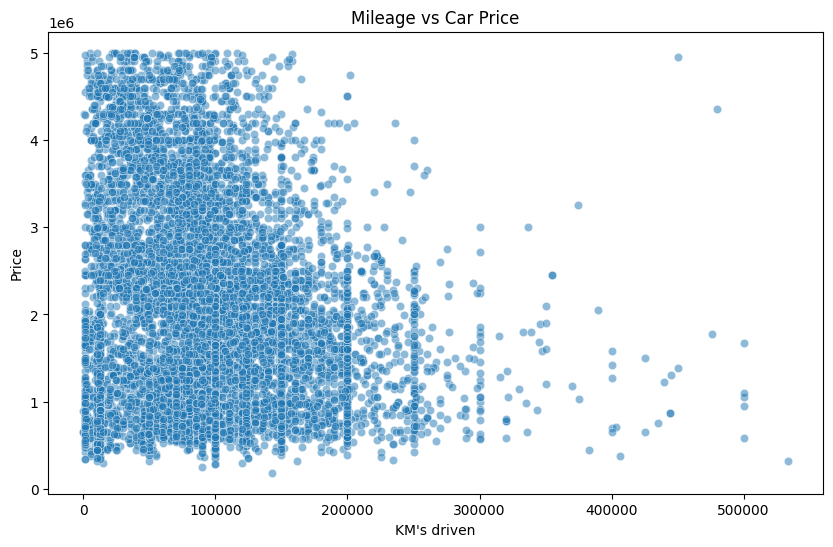

In [ ]:
# Mileage vs Price


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="KM's driven",
    y="Price",
    alpha=0.5
)

plt.title("Mileage vs Car Price")

plt.show()

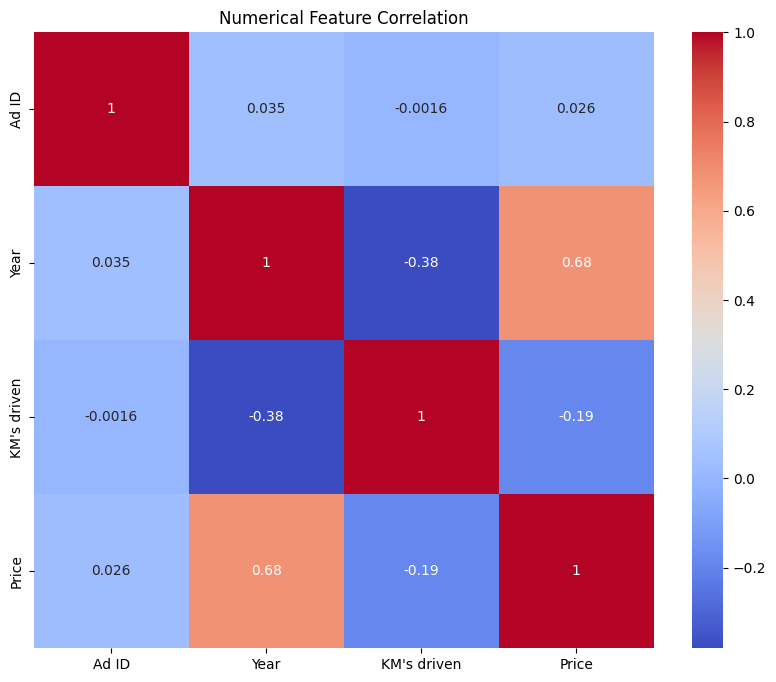

In [ ]:
# Correlation Heatmap

numeric_df = df.select_dtypes(
    include=np.number
)


plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()

In [8]:
# Phase 3: Data Cleaning and Preprocessing

# Create Working Copy

car_df = df.copy()

car_df.head()

# Missing Values

car_df.isnull().sum()

# Remove Unnecessary Columns

columns_to_drop = [
    "Ad ID",
    "Car Name",
    "Seller Location",
    "Description",
    "Car Features",
    "Car Profile"
]


car_df.drop(
    columns=columns_to_drop,
    inplace=True
)

print(car_df.columns)
display(car_df.head())

# Duplicate Rows


print(
    "Duplicate rows:",
    car_df.duplicated().sum()
)

car_df.drop_duplicates(
    inplace=True
)

print(
    "Updated Duplicate rows:", car_df.duplicated().sum()
)
print(car_df.shape)


# Rename Columns

car_df.rename(
    columns={
        "KM's driven": "Mileage",
        "Registration city": "Registration_City",
        "Car documents": "Documents"
    },
    inplace=True
)


print ( "Updates columns : ",  car_df.columns)

# Feature Engineering: Car Age


current_year = 2026

car_df["Car_Age"] = current_year - car_df["Year"]


display(car_df.head())



display(car_df["Year"].describe())

display(car_df["Mileage"].describe())

display(car_df["Price"].describe())

# Unique Values in Categorical Columns
categorical_columns = car_df.select_dtypes(
    include="object"
).columns


for col in categorical_columns:
    print("\n",col)
    print("Unique values:", car_df[col].nunique())


Index(['Make', 'Model', 'Year', 'KM's driven', 'Price', 'Fuel',
       'Registration city', 'Car documents', 'Assembly', 'Transmission',
       'Condition', 'Images URL's'],
      dtype='object')


,Make,Model,Year,KM's driven,Price,Fuel,Registration city,Car documents,Assembly,Transmission,Condition,Images URL's
0,Toyota,Passo,2021,54000,4190000,Petrol,Unregistered,Original,Imported,Automatic,Used,['https://images.olx.com.pk/thumbnails/4039460...
1,Suzuki,Ravi,2018,95000,1300000,Petrol,Karachi,Original,Local,Manual,Used,['https://images.olx.com.pk/thumbnails/4102504...
2,Suzuki,Bolan,2015,50000,800000,Petrol,Karachi,Original,Local,Manual,Used,['https://images.olx.com.pk/thumbnails/4139520...
3,Daihatsu,Move,2013,94000,2155000,Petrol,Lahore,Original,Imported,Automatic,Used,['https://images.olx.com.pk/thumbnails/3865337...
4,Suzuki,Swift,2011,126544,1440000,Petrol,Karachi,Original,Local,Manual,Used,['https://images.olx.com.pk/thumbnails/4143509...


Duplicate rows: 201
Updated Duplicate rows: 0
(8978, 12)
Updates columns :  Index(['Make', 'Model', 'Year', 'Mileage', 'Price', 'Fuel',
       'Registration_City', 'Documents', 'Assembly', 'Transmission',
       'Condition', 'Images URL's'],
      dtype='object')


,Make,Model,Year,Mileage,Price,Fuel,Registration_City,Documents,Assembly,Transmission,Condition,Images URL's,Car_Age
0,Toyota,Passo,2021,54000,4190000,Petrol,Unregistered,Original,Imported,Automatic,Used,['https://images.olx.com.pk/thumbnails/4039460...,5
1,Suzuki,Ravi,2018,95000,1300000,Petrol,Karachi,Original,Local,Manual,Used,['https://images.olx.com.pk/thumbnails/4102504...,8
2,Suzuki,Bolan,2015,50000,800000,Petrol,Karachi,Original,Local,Manual,Used,['https://images.olx.com.pk/thumbnails/4139520...,11
3,Daihatsu,Move,2013,94000,2155000,Petrol,Lahore,Original,Imported,Automatic,Used,['https://images.olx.com.pk/thumbnails/3865337...,13
4,Suzuki,Swift,2011,126544,1440000,Petrol,Karachi,Original,Local,Manual,Used,['https://images.olx.com.pk/thumbnails/4143509...,15


,Year
count,8978.000000
mean,2012.225551
std,6.040986
min,1989.000000
25%,2007.000000
50%,2013.000000
75%,2017.000000
max,2024.000000


,Mileage
count,8978.000000
mean,96931.665404
std,62045.134065
min,1.000000
25%,54000.000000
50%,92000.000000
75%,126000.000000
max,533528.000000


,Price
count,8.978000e+03
mean,2.033399e+06
std,1.157352e+06
min,1.850000e+05
25%,1.025000e+06
50%,1.800000e+06
75%,2.750000e+06
max,5.000000e+06



 Make
Unique values: 11

 Model
Unique values: 58

 Fuel
Unique values: 4

 Registration_City
Unique values: 61

 Documents
Unique values: 2

 Assembly
Unique values: 2

 Transmission
Unique values: 2

 Condition
Unique values: 1

 Images URL's
Unique values: 8976


In [9]:
# Phase 4 : Feature engineering

#removing unecessary columns
if "Condition" in car_df.columns:
    car_df.drop(columns=["Condition"], inplace=True)
if "Images URL's" in car_df.columns:
    car_df.drop(columns=["Images URL's"], inplace=True)
car_df.info()


# Import Libraries


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Feature Engineering


car_df["Mileage_Per_Year"] = (
    car_df["Mileage"] /
    (car_df["Car_Age"] + 1)
)

car_df.head()

# Features and Target


X = car_df.drop(columns=["Price"])

y = car_df["Price"]


# Feature Types

categorical_features = [
    "Make",
    "Model",
    "Fuel",
    "Registration_City",
    "Documents",
    "Assembly",
    "Transmission"
]

numerical_features = [
    "Year",
    "Mileage",
    "Car_Age",
    "Mileage_Per_Year"
]


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

# Preprocessing Pipeline


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


<class 'pandas.core.frame.DataFrame'>
Index: 8978 entries, 0 to 9178
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Make               8978 non-null   object
 1   Model              8978 non-null   object
 2   Year               8978 non-null   int64 
 3   Mileage            8978 non-null   int64 
 4   Price              8978 non-null   int64 
 5   Fuel               8978 non-null   object
 6   Registration_City  8978 non-null   object
 7   Documents          8978 non-null   object
 8   Assembly           8978 non-null   object
 9   Transmission       8978 non-null   object
 10  Car_Age            8978 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 841.7+ KB
Training samples: (7182, 11)
Testing samples : (1796, 11)


In [10]:
# Phase 5 : Model Training

# Import ML Models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


# Define Regression Models

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


# ============================================================
# Train Models
# ============================================================

results = {}

for name, model in models.items():

    print("\nTraining:", name)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor), # preprocessor: scaled + one hot encoding
            ("model", model)
        ]
    )

    # Training
    pipeline.fit(
        X_train,
        y_train
    )

    # Prediction
    y_pred = pipeline.predict(
        X_test
    )


    # Evaluation
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )


    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }


    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)





Training: Linear Regression
MAE: 251384.53241309646
RMSE: 346370.16120272945
R2 Score: 0.9103928347930761

Training: Decision Tree
MAE: 205819.08964365255
RMSE: 301423.3429363993
R2 Score: 0.9321397337955494

Training: Random Forest
MAE: 164423.07516472955
RMSE: 239227.91583217253
R2 Score: 0.9572549816150094

Training: Gradient Boosting
MAE: 207231.97369126978
RMSE: 289327.4647684228
R2 Score: 0.9374768114619889


,MAE,RMSE,R2 Score
Linear Regression,251384.532413,346370.161203,0.910393
Decision Tree,205819.089644,301423.342936,0.932140
Random Forest,164423.075165,239227.915832,0.957255
Gradient Boosting,207231.973691,289327.464768,0.937477


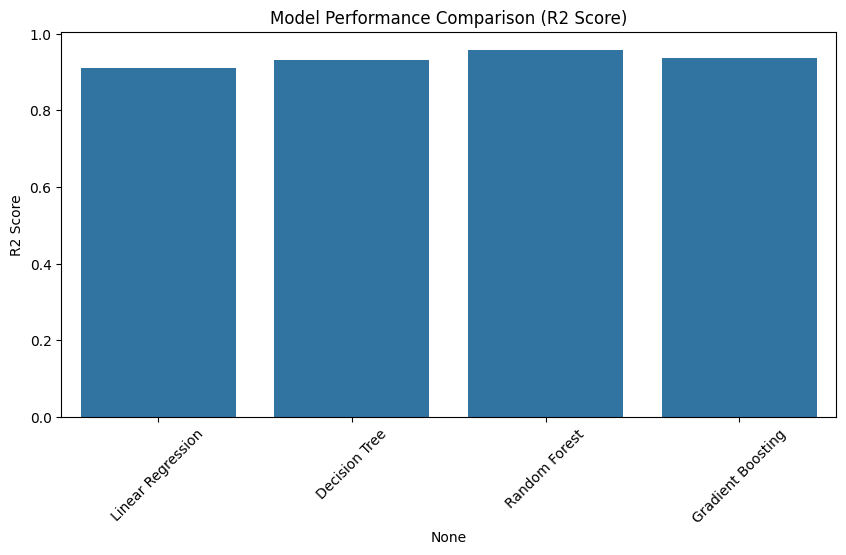

In [11]:
# Model Comparison


results_df = pd.DataFrame(results).T

display(results_df)

# R2 Score Comparison


plt.figure(figsize=(10,5))

sns.barplot(
    x=results_df.index,
    y=results_df["R2 Score"]
)

plt.xticks(rotation=45)

plt.title("Model Performance Comparison (R2 Score)")

plt.show()

In [12]:
# Best Model

best_model = results_df["R2 Score"].idxmax()

print(
    "Best Model:",
    best_model
)

Best Model: Random Forest


In [13]:
# Random Forest Pipeline


rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)


# HyperParameter Tuning

from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid


param_grid = {

    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        10,
        20
    ],

    "model__min_samples_split": [
        2,
        5
    ]
}

# ============================================================
# Grid Search
# ============================================================

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Mileage',
                                                                          'Car_Age',
                                                                          'Mileage_Per_Year']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Make',
                                                                          'Model',
                                                                          'Fuel',
                                                                          'Registration_City',
                                                                          'Documents',
                                                                          'Assembly',
                                                                          'Transmission'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='r2')

In [15]:
print(
    grid_search.best_params_
)

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(
    X_test
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 300}
MAE: 160184.0999366247
RMSE: 233557.54848491846
R2 Score: 0.95925731830664


In [17]:
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

In [18]:
import joblib
import os

# Ensure the 'models' directory exists
os.makedirs('models', exist_ok=True)

joblib.dump(
    best_rf,
    "models/car_price_prediction_model.pkl"
)

['models/car_price_prediction_model.pkl']

In [ ]:
print(car_df.shape)
car_df.info()

(8978, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 8978 entries, 0 to 9178
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Make               8978 non-null   object
 1   Model              8978 non-null   object
 2   Year               8978 non-null   int64 
 3   Mileage            8978 non-null   int64 
 4   Price              8978 non-null   int64 
 5   Fuel               8978 non-null   object
 6   Registration_City  8978 non-null   object
 7   Documents          8978 non-null   object
 8   Assembly           8978 non-null   object
 9   Transmission       8978 non-null   object
 10  Condition          8978 non-null   object
 11  Images URL's       8978 non-null   object
 12  Car_Age            8978 non-null   int64 
dtypes: int64(4), object(9)
memory usage: 982.0+ KB
